# Comparative Training of a Variational Quantum Classifier (VQC) - COBYLA vs SPSA

**Dataset:** NSL-KDD (PCA-16) | **Encoding:** Amplitude Encoding (4 Qubits)

This notebook implements the training of a Variational Quantum Classifier (VQC) to classify network traffic into Normal and Attack categories. The main objective is to conduct a comparative evaluation of two different optimization algorithms: 
1. **COBYLA** (Gradient-free, fast but prone to local minima).
2. **SPSA** (Stochastic, noise-resistant, ideal for quantum landscapes).

---
## 1. Importing Libraries & Settings

In [1]:
import os
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Scikit-Learn
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Qiskit Machine Learning & Algorithms
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import SPSA, COBYLA
from qiskit.primitives import StatevectorSampler

warnings.filterwarnings('ignore')

## 2. Data Loading and Transformation
The data has already undergone target encoding and dimensionality reduction (PCA) to 16 features. 
For the correct application of **Amplitude Encoding**, it is mathematically necessary for the vectors to undergo **$L^2$** normalization ($L^2$ normalization), so that the sum of their squares equals 1 ($||x||_2 = 1$). At the same time, the labels are converted to binary form (Normal $\rightarrow$ 0, Attack $\rightarrow$ 1).

In [ ]:
print("--- Loading and Preparing Data ---")
file_path = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/npz/nslkdd_pca_ready.npz')
data = np.load(file_path, allow_pickle=True)


xTrain_raw, xTest_raw = data['xTrain_norm'], data['xTest_norm']
yTrain_full, yTest_full = data['yTrain_bin'], data['yTest_bin']

xTrain_full = normalize(xTrain_raw, norm='l2', axis=1)
xTest_full = normalize(xTest_raw, norm='l2', axis=1)


print("Τα δεδομένα φορτώθηκαν και μετασχηματίστηκαν επιτυχώς.")
print(f"-> Διαστάσεις Συνόλου Εκπαίδευσης (Train): {xTrain_full.shape}")
print(f"-> Διαστάσεις Συνόλου Δοκιμής (Test):       {xTest_full.shape}")

--- Φόρτωση και Προετοιμασία Δεδομένων ---
Τα δεδομένα φορτώθηκαν και μετασχηματίστηκαν επιτυχώς.
-> Διαστάσεις Συνόλου Εκπαίδευσης (Train): (20155, 16)
-> Διαστάσεις Συνόλου Δοκιμής (Test):       (5037, 16)


## 3. Building Quantum Architecture & Tools
The circuit consists of the `raw_feature_vector` (Amplitude Encoding) and the `RealAmplitudes` Ansatz (reps=5). 
To avoid variable conflicts during comparison, a “factory” function (`create_callback`) is created that generates independent graphs for each optimizer.

In [ ]:
NUM_QUBITS = 4
feature_map = raw_feature_vector(feature_dimension=16)
ansatz = RealAmplitudes(num_qubits=NUM_QUBITS, reps=5)

print(f"Κύκλωμα έτοιμο. Εκπαιδεύσιμες Παράμετροι: {ansatz.num_parameters}")

def create_callback(optimizer_name, color):
    history = []
    
    def callback(weights, obj_func_eval):
        clear_output(wait=True)
        history.append(obj_func_eval)
        
        plt.figure(figsize=(10, 5))
        plt.title(f"Εκπαίδευση VQC - {optimizer_name}", fontsize=14, pad=10)
        plt.plot(history, label="Loss", color=color, alpha=0.7)
        
        if len(history) > 10:
            ma = np.convolve(history, np.ones(10)/10, mode='valid')
            plt.plot(range(9, len(history)), ma, label="Trend (MA-10)", color="black", linestyle="--")
            
        plt.xlabel("Iterations", fontsize=11)
        plt.ylabel("Cross-Entropy Loss", fontsize=11)
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()
        print(f"[{optimizer_name}] rep: {len(history)} | Loss: {obj_func_eval:.4f}")
        
    return callback, history


save_folder = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/models/')
os.makedirs(save_folder, exist_ok=True)

Κύκλωμα έτοιμο. Εκπαιδεύσιμες Παράμετροι: 24


## 4. Experiment 1: Training with COBYLA
**COBYLA** is fast, but because it uses local linear approximations, it often gets “trapped” in local minima of the quantum space, causing the loss to stop improving prematurely.

In [ ]:
print("Starting Training with COBYLA...")
cobyla_callback, cobyla_history = create_callback("COBYLA", "#1E88E5") # Μπλε χρώμα

vqc_cobyla = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=500),
    sampler=StatevectorSampler(),
    callback=cobyla_callback
)

start_time = time.time()
vqc_cobyla.fit(xTrain_full, yTrain_full)
print(f"\nCOBYLA finished in {(time.time() - start_time) / 60:.2f} λεπτά.")

cobyla_path = os.path.join(save_folder, 'vqc_cobyla.model')
vqc_cobyla.to_dill(cobyla_path)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Εκκίνηση Εκπαίδευσης με COBYLA...


## 5. Experiment 2: Training with SPSA
The **SPSA** requires more time, but its stochastic nature (the introduction of noise into the parameters) allows it to navigate effectively through barren plateaus, achieving deeper convergence.

In [ ]:
print("Starting Training with SPSA...")
spsa_callback, spsa_history = create_callback("SPSA", "#D81B60") 

vqc_spsa = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=SPSA(maxiter=500),
    sampler=StatevectorSampler(),
    callback=spsa_callback
)

start_time = time.time()
vqc_spsa.fit(xTrain_full, yTrain_full)
print(f"\nSPSA finished in {(time.time() - start_time) / 60:.2f} λεπτά.")

spsa_path = os.path.join(save_folder, 'vqc_spsa.model')
vqc_spsa.to_dill(spsa_path)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


--- 0. Άνοιγμα δεδομένων από: /home/aggelos/Documents/projects/Quantum-IDS-NSLKDD/npz/nslkdd_pca_ready.npz ---
✅ Δεδομένα έτοιμα (L2 Normalized).
🚀 Ξεκινάει ο Μαραθώνιος εκπαίδευσης σε 20155 δείγματα...


## 6. Comparative Evaluation (COBYLA vs. SPSA)
Inference is performed on the test set (5,037 records) for both models. The metrics are extracted, and side-by-side confusion matrices are plotted for direct comparison.

Φόρτωση μοντέλων από τον δίσκο...
Τα μοντέλα φορτώθηκαν επιτυχώς!

Εξαγωγή προβλέψεων στο Test Set...
REPORT COBYLA:
              precision    recall  f1-score   support

  Normal (0)       0.90      0.87      0.89      2690
  Attack (1)       0.86      0.89      0.88      2347

    accuracy                           0.88      5037
   macro avg       0.88      0.88      0.88      5037
weighted avg       0.88      0.88      0.88      5037

REPORT SPSA:
              precision    recall  f1-score   support

  Normal (0)       0.89      0.89      0.89      2690
  Attack (1)       0.87      0.88      0.87      2347

    accuracy                           0.88      5037
   macro avg       0.88      0.88      0.88      5037
weighted avg       0.88      0.88      0.88      5037

Το γράφημα αποθηκεύτηκε ως 'vqc_optimizer_comparison.png'


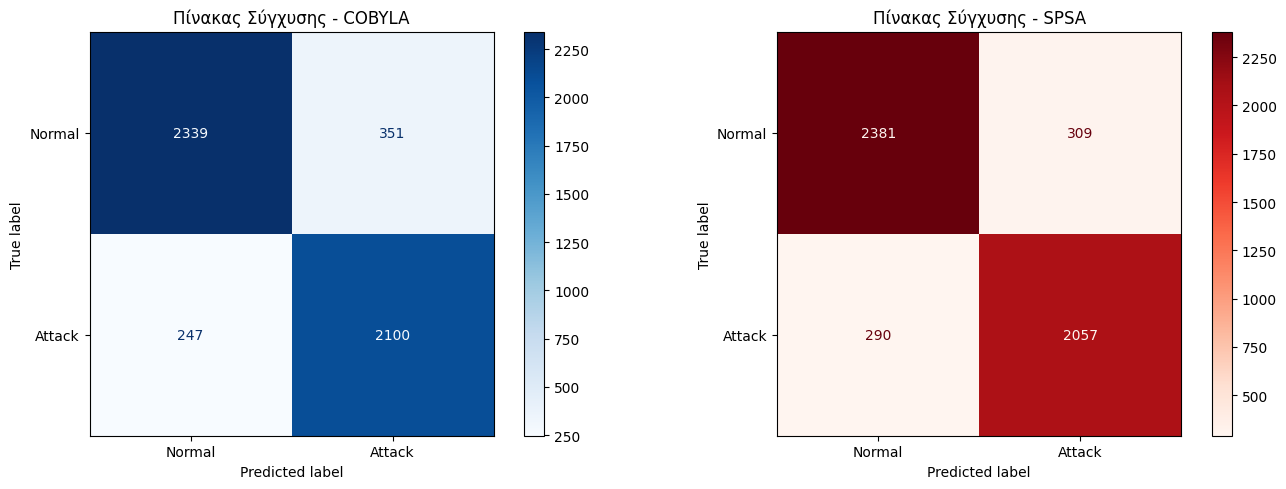

In [ ]:
save_folder = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/models/')
cobyla_path = os.path.join(save_folder, 'vqc_cobyla.model')
spsa_path = os.path.join(save_folder, 'vqc_spsa_final_88acc.model') # Το ακριβές όνομα που ζήτησες

print("Φόρτωση μοντέλων από τον δίσκο...")
try:
    vqc_cobyla = VQC.from_dill(cobyla_path)
    vqc_spsa = VQC.from_dill(spsa_path)
except AttributeError:
    # Σε περίπτωση που είχαν σωθεί με την παλιά μέθοδο .save()
    vqc_cobyla = VQC.load(cobyla_path)
    vqc_spsa = VQC.load(spsa_path)
print("Τα μοντέλα φορτώθηκαν επιτυχώς!\n")

# 2. Ο ΚΩΔΙΚΑΣ ΣΟΥ ΓΙΑ ΠΡΟΒΛΕΨΕΙΣ ΚΑΙ ΑΞΙΟΛΟΓΗΣΗ
def get_predictions(model, x_test):
    y_pred_raw = model.predict(x_test)
    if len(y_pred_raw.shape) > 1 and y_pred_raw.shape[1] > 1:
        return np.argmax(y_pred_raw, axis=1)
    return y_pred_raw

# Προβλέψεις (μπορεί να πάρει λίγο χρόνο για τα 5.000 δείγματα)
print("Εξαγωγή προβλέψεων στο Test Set...")
y_pred_cobyla = get_predictions(vqc_cobyla, xTest_full)
y_pred_spsa = get_predictions(vqc_spsa, xTest_full)

print("="*50)
print("REPORT COBYLA:")
print(classification_report(yTest_full, y_pred_cobyla, target_names=["Normal (0)", "Attack (1)"]))
print("="*50)
print("REPORT SPSA:")
print(classification_report(yTest_full, y_pred_spsa, target_names=["Normal (0)", "Attack (1)"]))

# Οπτικοποίηση δίπλα-δίπλα
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cobyla = confusion_matrix(yTest_full, y_pred_cobyla)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_cobyla, display_labels=["Normal", "Attack"])
disp1.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title("Πίνακας Σύγχυσης - COBYLA")

cm_spsa = confusion_matrix(yTest_full, y_pred_spsa)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_spsa, display_labels=["Normal", "Attack"])
disp2.plot(cmap='Reds', ax=axes[1], values_format='d')
axes[1].set_title("Πίνακας Σύγχυσης - SPSA")

plt.tight_layout()
plt.savefig("vqc_optimizer_comparison.png", dpi=300)
print("Το γράφημα αποθηκεύτηκε ως 'vqc_optimizer_comparison.png'")
plt.show()

--- 🚀 Εκκίνηση Κλασικού Νευρωνικού (4-Node Bottleneck) ---

📊 TINY MLP - 4 NODES (Χρόνος: 4.6036 sec | Παράμετροι: 73)
              precision    recall  f1-score   support

  Normal (0)       0.97      0.97      0.97      2690
  Attack (1)       0.97      0.97      0.97      2347

    accuracy                           0.97      5037
   macro avg       0.97      0.97      0.97      5037
weighted avg       0.97      0.97      0.97      5037



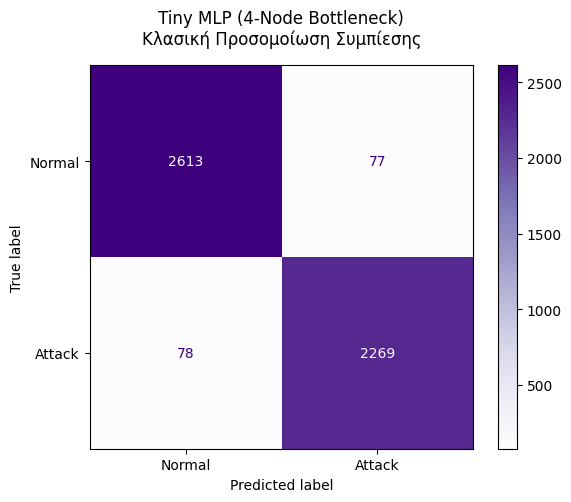

In [3]:
import time
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("--- 🚀 Εκκίνηση Κλασικού Νευρωνικού (4-Node Bottleneck) ---")

# Δημιουργία του "Συμπιεσμένου" MLP
# 16 Είσοδοι -> 4 Κρυφοί Νευρώνες -> 1 Έξοδος
mlp_model = MLPClassifier(
    hidden_layer_sizes=(4,),  # Εδώ είναι ο "λαιμός μπουκαλιού" των 4 κόμβων
    activation='relu',        # Κλασική μη-γραμμική συνάρτηση ενεργοποίησης
    solver='adam',            # Ο standard optimizer για νευρωνικά
    max_iter=1000, 
    random_state=42
)

start_time = time.time()
mlp_model.fit(xTrain_full, yTrain_full)
mlp_time = time.time() - start_time

y_pred_mlp = mlp_model.predict(xTest_full)

# --- ΕΚΤΥΠΩΣΗ ΑΠΟΤΕΛΕΣΜΑΤΩΝ ---
print("\n" + "="*50)
print(f"📊 TINY MLP - 4 NODES (Χρόνος: {mlp_time:.4f} sec | Παράμετροι: 73)")
print("="*50)
print(classification_report(yTest_full, y_pred_mlp, target_names=["Normal (0)", "Attack (1)"]))

# --- ΟΠΤΙΚΟΠΟΙΗΣΗ ΠΙΝΑΚΑ ΣΥΓΧΥΣΗΣ ---
cm_mlp = confusion_matrix(yTest_full, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=["Normal", "Attack"])

fig, ax = plt.subplots(figsize=(6, 5))
disp_mlp.plot(cmap='Purples', ax=ax, values_format='d')
plt.title("Tiny MLP (4-Node Bottleneck)\nΚλασική Προσομοίωση Συμπίεσης", pad=15)
plt.tight_layout()
plt.savefig("mlp_bottleneck_benchmark.png", dpi=300)
plt.show()